<a href="https://colab.research.google.com/github/zakari90/machine-learning/blob/main/kmeans_cistomer_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

file_path = "/content/drive/MyDrive/hsoub ai/machine learning/unsupervised learning/shopping-data.csv"
df = pd.read_csv(file_path)
X = df.drop(columns=["CustomerID"])

X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [15]:
from sklearn.preprocessing import MinMaxScaler

data_scaler = MinMaxScaler(feature_range=(1,99))

data_scaler.fit(X)

TX=data_scaler.transform(X)
print(TX)

X['Income']=TX[:,0]

X['Score']=TX[:,1]

[[ 1.         39.        ]
 [ 1.         81.        ]
 [ 1.80327869  6.        ]
 [ 1.80327869 77.        ]
 [ 2.60655738 40.        ]
 [ 2.60655738 76.        ]
 [ 3.40983607  6.        ]
 [ 3.40983607 94.        ]
 [ 4.21311475  3.        ]
 [ 4.21311475 72.        ]
 [ 4.21311475 14.        ]
 [ 4.21311475 99.        ]
 [ 5.01639344 15.        ]
 [ 5.01639344 77.        ]
 [ 5.01639344 13.        ]
 [ 5.01639344 79.        ]
 [ 5.81967213 35.        ]
 [ 5.81967213 66.        ]
 [ 7.42622951 29.        ]
 [ 7.42622951 98.        ]
 [ 8.2295082  35.        ]
 [ 8.2295082  73.        ]
 [ 9.03278689  5.        ]
 [ 9.03278689 73.        ]
 [11.44262295 14.        ]
 [11.44262295 82.        ]
 [11.44262295 32.        ]
 [11.44262295 61.        ]
 [12.24590164 31.        ]
 [12.24590164 87.        ]
 [13.04918033  4.        ]
 [13.04918033 73.        ]
 [15.45901639  4.        ]
 [15.45901639 92.        ]
 [15.45901639 14.        ]
 [15.45901639 81.        ]
 [16.26229508 17.        ]
 

In [24]:
# Import KMeans for clustering from scikit-learn
from sklearn.cluster import KMeans

# Select only 'Income' and 'Score' columns from DataFrame X for clustering
X = X[['Income','Score']]

# Import silhouette_score to evaluate clustering performance
from sklearn.metrics import silhouette_score

# Define a range of cluster numbers to test
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
# Initialize variable to store the maximum silhouette score found
max_silhouette_score=0
# Initialize variable to store the number of clusters that yielded the maximum silhouette score
best_n_clusters=0

# Loop through each number of clusters in the defined range
for n_clusters in range_n_clusters:

    # Initialize KMeans model with the current number of clusters
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added random_state and n_init for reproducibility and best practice
    # Fit the KMeans model to the data X
    model.fit(X)
    print("**********************")
    print(model.cluster_centers_)
    print(model.labels_[0])
    print("**********************")

    # Calculate the average silhouette score for the current clustering
    silhouette_avg = silhouette_score(X, model.labels_)
    # Check if the current silhouette score is better than the maximum found so far
    if silhouette_avg>max_silhouette_score:
        # Update the maximum silhouette score
        max_silhouette_score=silhouette_avg
        # Update the best number of clusters
        best_n_clusters=n_clusters
    # Print the silhouette score for the current number of clusters
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    round(silhouette_avg,2),
    )
# Print the best number of clusters and its corresponding silhouette score
print("Best n_cluster= ",best_n_clusters, " with silhouette score= ", round(max_silhouette_score,2))

**********************
[[38.10425493 73.47191011]
 [37.19096145 31.54054054]]
1
**********************
For n_clusters = 2 The average silhouette_score is : 0.33
**********************
[[46.80295082 16.46      ]
 [26.11874169 54.18018018]
 [58.46532156 82.12820513]]
1
**********************
For n_clusters = 3 The average silhouette_score is : 0.45
**********************
[[27.71704918 56.48      ]
 [10.0805417  20.91304348]
 [58.46532156 82.12820513]
 [58.83606557 18.63157895]]
1
**********************
For n_clusters = 4 The average silhouette_score is : 0.5
**********************
[[ 9.61698957 79.36363636]
 [59.8        17.11428571]
 [58.46532156 82.12820513]
 [33.36915604 49.51851852]
 [10.0805417  20.91304348]]
4
**********************
For n_clusters = 5 The average silhouette_score is : 0.56
**********************
[[33.36915604 49.51851852]
 [59.8        17.11428571]
 [75.8509687  82.72727273]
 [ 9.61698957 79.36363636]
 [10.0805417  20.91304348]
 [51.6352459  81.89285714]]
4
*******

In [17]:
n_clusters=best_n_clusters
kmeans = KMeans(n_clusters=n_clusters,random_state=0)

kmeans.fit(X)

KMeans(n_clusters=5, random_state=0)

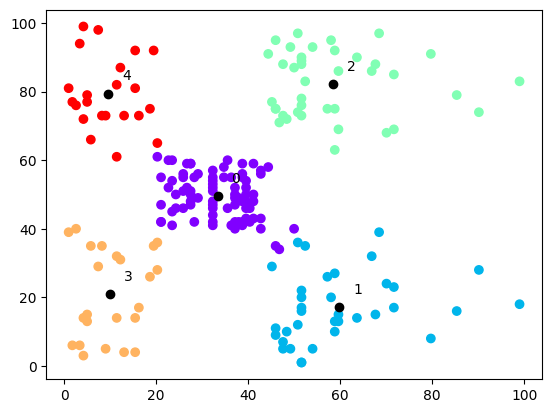

In [20]:
import matplotlib.pyplot as plt

X1 = X["Income"]

Y = X["Score"]

plt.scatter(X1,Y, c=kmeans.labels_,  cmap='rainbow')

XCenters = kmeans.cluster_centers_[:,0]
YCenters = kmeans.cluster_centers_[:,1]

plt.scatter(XCenters ,YCenters, color='black')

for i in range(best_n_clusters):
    plt.annotate(
        i,
        xy=(XCenters[i], YCenters[i]),
        textcoords='offset points',
        xytext=(10, 10))

plt.show()

In [19]:
cluster_map = pd.DataFrame()
cluster_map['CustomerID'] = df['CustomerID']

cluster_map['cluster'] = kmeans.labels_

cluster_map[cluster_map.cluster == 2]

,CustomerID,cluster
123,124,2
125,126,2
127,128,2
129,130,2
131,132,2
133,134,2
135,136,2
137,138,2
139,140,2
141,142,2
